# DL Astronomy

## Imports

In [1]:
import os
import shutil

import kagglehub
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras import callbacks

/teamspace/studios/this_studio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1775734425.371568    2903 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Dataset loading

In [2]:
path = kagglehub.dataset_download("jaimetrickz/galaxy-zoo-2-images")
filename = "gz2_filename_mapping.csv"
filepath = os.path.join(path, filename)
df_mapping = pd.read_csv(filepath)

In [3]:
url = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"
df_gz2_hart = pd.read_csv(url, compression="gzip")

## EDA

### Dataset analysis

In [ ]:
df_mapping.head()

,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


In [5]:
df_mapping.shape

(355990, 3)

In [ ]:
unique_values = len(df_mapping["objid"].unique())
print(f"\nUnique values : {unique_values}")


Unique values : 325651


In [7]:
image_dir = Path(os.path.join(path, "images_gz2", "images"))

count = len(list(image_dir.glob("*.jpg")))

print(f"Images: {count}")

Images: 243434


In [ ]:
df_gz2_hart.head()

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [9]:
df_gz2_hart.shape

(239695, 231)

In [10]:
for column in df_gz2_hart.columns:
    print(column)

dr7objid
ra
dec
rastring
decstring
sample
gz2_class
total_classifications
total_votes
t01_smooth_or_features_a01_smooth_count
t01_smooth_or_features_a01_smooth_weight
t01_smooth_or_features_a01_smooth_fraction
t01_smooth_or_features_a01_smooth_weighted_fraction
t01_smooth_or_features_a01_smooth_debiased
t01_smooth_or_features_a01_smooth_flag
t01_smooth_or_features_a02_features_or_disk_count
t01_smooth_or_features_a02_features_or_disk_weight
t01_smooth_or_features_a02_features_or_disk_fraction
t01_smooth_or_features_a02_features_or_disk_weighted_fraction
t01_smooth_or_features_a02_features_or_disk_debiased
t01_smooth_or_features_a02_features_or_disk_flag
t01_smooth_or_features_a03_star_or_artifact_count
t01_smooth_or_features_a03_star_or_artifact_weight
t01_smooth_or_features_a03_star_or_artifact_fraction
t01_smooth_or_features_a03_star_or_artifact_weighted_fraction
t01_smooth_or_features_a03_star_or_artifact_debiased
t01_smooth_or_features_a03_star_or_artifact_flag
t02_edgeon_a04_yes_c

In [ ]:
unique_values = len(df_gz2_hart["gz2_class"].unique())
print(f"Unique values: {unique_values}")

Unique values: 818


In [ ]:
for class_name in sorted(df_gz2_hart["gz2_class"].unique()):
    print(class_name)

A
Ec
Ec(d)
Ec(i)
Ec(l)
Ec(m)
Ec(o)
Ec(r)
Ec(u)
Ei
Ei(d)
Ei(i)
Ei(l)
Ei(m)
Ei(o)
Ei(r)
Ei(u)
Er
Er(d)
Er(i)
Er(l)
Er(m)
Er(o)
Er(r)
Er(u)
SBa
SBa(d)
SBa(i)
SBa(m)
SBa(o)
SBa(r)
SBa+m
SBa+t
SBa+t(o)
SBa1l
SBa1l(m)
SBa1l(u)
SBa1m
SBa1t
SBa1t(i)
SBa2l
SBa2l(m)
SBa2l(r)
SBa2m
SBa2m(i)
SBa2m(m)
SBa2m(r)
SBa2t
SBa2t(i)
SBa2t(l)
SBa2t(r)
SBa3l(r)
SBa3t
SBa4m
SBa?l
SBa?m
SBa?m(m)
SBa?t
SBa?t(o)
SBa?t(r)
SBb
SBb(d)
SBb(i)
SBb(l)
SBb(m)
SBb(o)
SBb(r)
SBb(u)
SBb+l
SBb+l(i)
SBb+l(m)
SBb+l(o)
SBb+l(r)
SBb+m
SBb+m(i)
SBb+m(m)
SBb+m(o)
SBb+m(r)
SBb+t
SBb+t(d)
SBb+t(i)
SBb+t(m)
SBb+t(o)
SBb+t(r)
SBb1l
SBb1l(d)
SBb1l(i)
SBb1l(l)
SBb1l(m)
SBb1l(o)
SBb1l(r)
SBb1l(u)
SBb1m
SBb1m(d)
SBb1m(i)
SBb1m(m)
SBb1m(o)
SBb1m(r)
SBb1m(u)
SBb1t
SBb1t(d)
SBb1t(i)
SBb1t(l)
SBb1t(m)
SBb1t(o)
SBb1t(r)
SBb1t(u)
SBb2l
SBb2l(d)
SBb2l(i)
SBb2l(l)
SBb2l(m)
SBb2l(o)
SBb2l(r)
SBb2l(u)
SBb2m
SBb2m(d)
SBb2m(i)
SBb2m(l)
SBb2m(m)
SBb2m(o)
SBb2m(r)
SBb2m(u)
SBb2t
SBb2t(d)
SBb2t(i)
SBb2t(l)
SBb2t(m)
SBb2t(o)
SBb2t(r)
SBb2t(u)
SBb3l
SBb

![Hubble-Galaxy-Classification](https://earthhow.com/wp-content/uploads/2018/08/Hubble-Galaxy-Classification-678x378.png)

In [13]:
def simplify(label):
    if label.startswith("E"):
        return "elliptical"
    elif label.startswith("S"):
        return "spiral"
    else:
        return "other"

df_simple_class = df_gz2_hart.copy()

df_simple_class["simple_class"] = df_simple_class["gz2_class"].apply(simplify)

### Target distribution

simple_class
spiral        141430
elliptical     97670
other            595
Name: count, dtype: int64


<Axes: xlabel='simple_class', ylabel='count'>

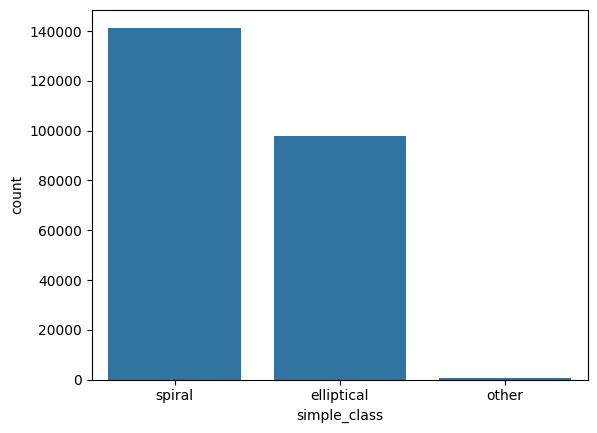

In [14]:

print(df_simple_class["simple_class"].value_counts())
sns.countplot(data=df_simple_class, x="simple_class")


### Sample images

(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)
(424, 424)


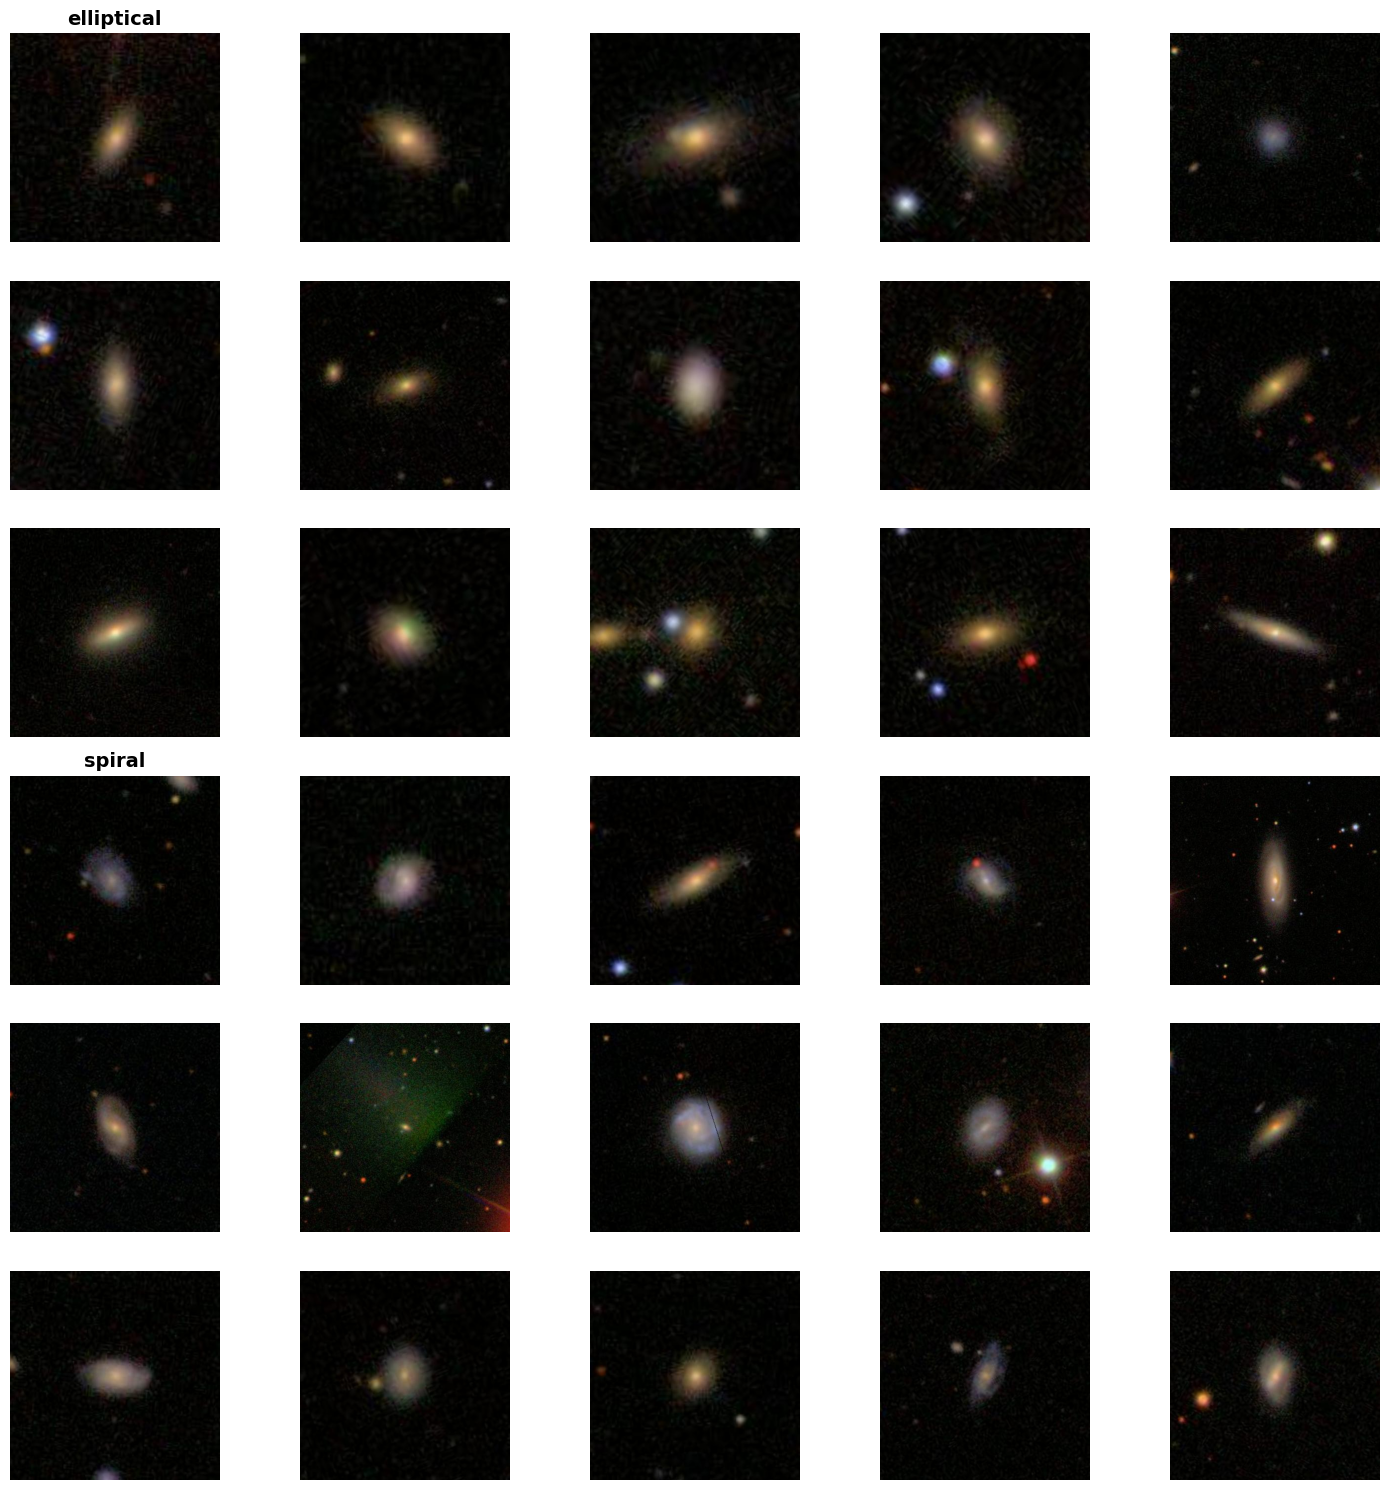

In [15]:
SEED = 42

mapping = dict(zip(df_mapping["objid"], df_mapping["asset_id"]))

classe_names = ["elliptical", "spiral"]

num_rows_per_class = 3
num_cols = 5

fig, axes = plt.subplots(len(classe_names) * num_rows_per_class, num_cols, figsize=(15, 15))

for c_index, class_name in enumerate(classe_names):

    df_class = df_simple_class[df_simple_class["simple_class"] == class_name]
    sample = df_class.sample(num_rows_per_class * num_cols, random_state=SEED)

    for i in range(num_rows_per_class):
        for j in range(num_cols):

            objid = sample.iloc[i * num_cols + j]["dr7objid"]
            filename = mapping[objid]
            img_path = image_dir / f"{filename}.jpg"

            img = Image.open(img_path)
            print(img.size)

            ax = axes[c_index * num_rows_per_class + i, j]

            if img_path.exists():
                img = plt.imread(img_path)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, "missing", ha="center")

            ax.axis("off")

            if i == 0 and j == 0:
                ax.set_title(class_name, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## Preprocessing

### Cleaning

In [16]:
df = df_simple_class.copy()

df = df[df["simple_class"] != "other"]

df["filepath"] = df["dr7objid"].map(mapping).apply(
    lambda x: image_dir / f"{x}.jpg"
)

df = df[df["filepath"].apply(lambda p: p.exists())]

len(df)

239029

### Reducing

In [17]:
num_images_per_class = 5000

data_dir = Path("data")
if data_dir.exists():
    shutil.rmtree(data_dir)

data_dir.mkdir()

for c_index, class_name in enumerate(classe_names):

    df_class = df[df["simple_class"] == class_name]
    sample = df_class.sample(num_images_per_class, random_state=SEED)

    class_dir = data_dir / class_name
    class_dir.mkdir()

    for i in range(num_images_per_class):
         
        objid = sample.iloc[i]["dr7objid"]
        filename = mapping[objid]
        src_path = image_dir / f"{filename}.jpg"
        tgt_path = class_dir / f"{filename}.jpg"

        shutil.copy(src_path, tgt_path)

### Train / val / test split

In [18]:
SEED=42
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
VALIDATION_SPLIT = 0.2

data_dir = Path("data")

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

Found 10000 files belonging to 2 classes.
Using 8000 files for training.


E0000 00:00:1775734629.394175    2903 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 10000 files belonging to 2 classes.
Using 2000 files for validation.


### Data augmentation

In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

### Dataset preparation

In [20]:
def prepare_dataset(ds, augment=False, shuffle=True):
    normalization = lambda x, y: (preprocess_input(x), y)
    ds = ds.map(normalization, num_parallel_calls=tf.data.AUTOTUNE)
    
    """
    if augment:
        augmentation = lambda x, y: (data_augmentation(x, training=True), y)
        ds = ds.map(augmentation, num_parallel_calls=tf.data.AUTOTUNE)
    """
    
    if shuffle:
        ds = ds.shuffle(1000)
    
    #ds = ds.cache()
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return ds

train_ds_prepared = prepare_dataset(train_ds, augment=True, shuffle=True)
val_ds_prepared = prepare_dataset(val_ds, augment=False, shuffle=False)
test_ds_prepared = prepare_dataset(test_ds, augment=False, shuffle=False)

## GPU configuration

In [21]:
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) detected: {len(gpus)}")
    else:
        print("No GPU detected")
except Exception as e:
    print(f"GPU configuration: {e}")

No GPU detected


## Transfer learning

### Model loading

In [22]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

layers_length = len(base_model.layers)
print(f"Layers: {layers_length}")

base_model.summary()

Layers: 155


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

### Freezing layers

In [23]:
base_model.trainable = False

### Model building

In [24]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = Dropout(0.3)(x)
x = Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

model_frozen = tf.keras.Model(inputs, outputs, name="MobileNetV2")

### Compilation

In [25]:

FINE_TUNE_LR = 0.001

model_frozen.compile(
    optimizer=tf.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Model training

In [26]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "model/best_model_frozen.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=0
)

EPOCHS_FROZEN = 30

print(f"Configuration:")
print(f"  - Epochs max: {EPOCHS_FROZEN}")
print(f"  - Patience  : 10 epochs")
print(f"  - LR initial: 0.001")
print(f"  - LR min    : 1e-7\n")

history_frozen = model_frozen.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FROZEN,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print(f"Epochs completed: {len(history_frozen.history['loss'])}")

best_val_acc = max(history_frozen.history['val_accuracy'])
best_epoch = history_frozen.history['val_accuracy'].index(best_val_acc) + 1
print(f"Best val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

Configuration:
  - Epochs max: 30
  - Patience  : 10 epochs
  - LR initial: 0.001
  - LR min    : 1e-7

Epoch 1/30


W0000 00:00:1775734645.697405   21617 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1775734645.701809   21196 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1775734645.865076   21196 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1775734645.943679   21196 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.
W0000 00:00:1775734646.039482   21196 cpu_allocator_impl.cc:82] Allocation of 156905472 exceeds 10% of free system memory.
W0000 00:00:1775734646.128684   21196 cpu_allocator_impl.cc:82] Allocation of 38535168 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 218s 815ms/step - accuracy: 0.6959 - loss: 1.5523 - val_accuracy: 0.7450 - val_loss: 0.7715 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 154s 597ms/step - accuracy: 0.7249 - loss: 0.7092 - val_accuracy: 0.7520 - val_loss: 0.6237 - learning_rate: 0.0010
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 185s 725ms/step - accuracy: 0.7205 - loss: 0.6320 - val_accuracy: 0.7278 - val_loss: 0.6005 - learning_rate: 0.0010
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 210s 815ms/step - accuracy: 0.7272 - loss: 0.6079 - val_accuracy: 0.7500 - val_loss: 0.5679 - learning_rate: 0.0010
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 207s 594ms/step - accuracy: 0.7225 - loss: 0.5929 - val_accuracy: 0.7339 - val_loss: 0.5866 - learning_rate: 0.0010
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 179s 697ms/step - accuracy: 0.7306 - loss: 0.5864 - val_accuracy: 0.7460 - val_loss: 0.5522 - learning_rate: 0.0010
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 135s 523ms/step - accuracy: 0.7309 

### Training evaluation

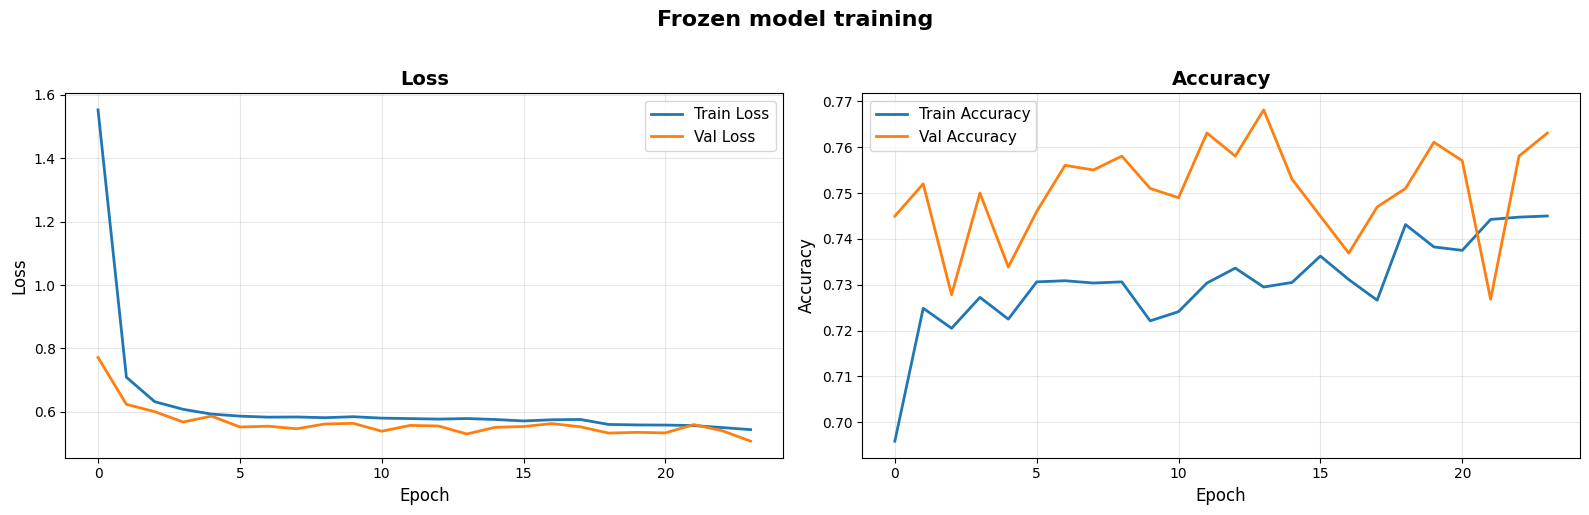

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_frozen.history["loss"], label="Train Loss", linewidth=2)
axes[0].plot(history_frozen.history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Loss", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(history_frozen.history["accuracy"], label="Train Accuracy", linewidth=2)
axes[1].plot(history_frozen.history["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Accuracy", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle("Frozen model training", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Fine tuning

### Unfreezing layers

In [28]:

base_model.trainable = True

fine_tune_at = round(layers_length * 2 / 3)

for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= fine_tune_at)

trainable_count = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
total = trainable_count + non_trainable_count

print(f"- Trainable: {trainable_count:,} ({trainable_count/total*100:.1f}%)")
print(f"- Non trainable: {non_trainable_count:,}\n")

- Trainable: 2,183,297 (84.4%)
- Non trainable: 402,880



### Compilation

In [29]:
FINE_TUNE_LR = 1e-5

model_frozen.compile(
    optimizer=tf.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_finetuned = model_frozen

### Model training

In [31]:
early_stopping_ft = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

reduce_lr_ft = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-8,
    verbose=1
)

checkpoint_ft = callbacks.ModelCheckpoint(
    "model/best_model_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=0
)

EPOCHS_FINETUNE = 50

print(f"Configuration:")
print(f"  - Epochs max: {EPOCHS_FINETUNE}")
print(f"  - Patience  : 20 epochs")
print(f"  - LR initial: 1e-5")
print(f"  - LR min    : 1e-8\n")

history_finetuned = model_finetuned.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stopping_ft, reduce_lr_ft, checkpoint_ft],
    verbose=1
)

print(f"Epochs completed: {len(history_finetuned.history['loss'])}")

best_val_acc = max(history_finetuned.history["val_accuracy"])
best_epoch = history_finetuned.history['val_accuracy'].index(best_val_acc) + 1
print(f"Best val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

frozen_best = max(history_frozen.history['val_accuracy'])
improvement = (best_val_acc - frozen_best) * 100
print(f"\nComparison:")
print(f"   - Frozen    : {frozen_best*100:.2f}%")
print(f"   - Fine-tuned: {best_val_acc*100:.2f}%")

Configuration:
  - Epochs max: 50
  - Patience  : 20 epochs
  - LR initial: 1e-5
  - LR min    : 1e-8

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 255s 996ms/step - accuracy: 0.7721 - loss: 0.5219 - val_accuracy: 0.7248 - val_loss: 0.5867 - learning_rate: 1.0000e-05
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 234s 919ms/step - accuracy: 0.7896 - loss: 0.4910 - val_accuracy: 0.7188 - val_loss: 0.6043 - learning_rate: 1.0000e-05
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 239s 939ms/step - accuracy: 0.8089 - loss: 0.4609 - val_accuracy: 0.7308 - val_loss: 0.6009 - learning_rate: 1.0000e-05
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 247s 963ms/step - accuracy: 0.8260 - loss: 0.4299 - val_accuracy: 0.7399 - val_loss: 0.5701 - learning_rate: 1.0000e-05
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.8420 - loss: 0.4068 - val_accuracy: 0.7762 - val_loss: 0.5205 - learning_rate: 1.0000e-05
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.8612 - loss: 0.3727 - val_accurac

### Training evaluation

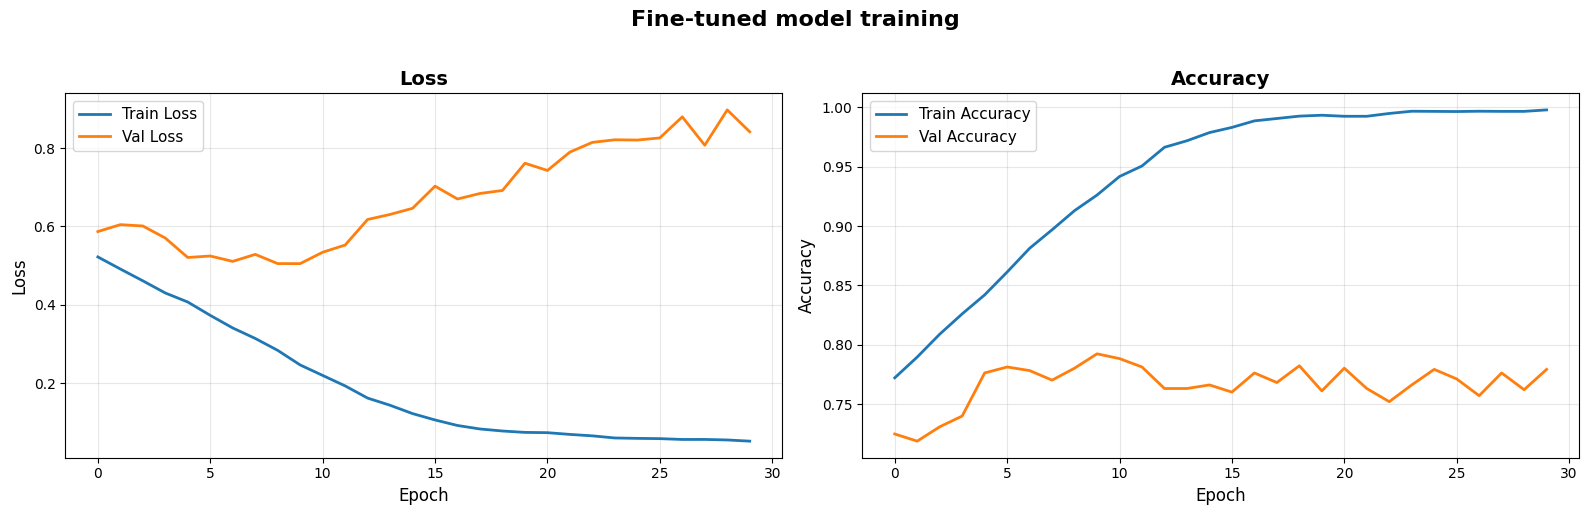

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_finetuned.history["loss"], label="Train Loss", linewidth=2)
axes[0].plot(history_finetuned.history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Loss", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(history_finetuned.history["accuracy"], label="Train Accuracy", linewidth=2)
axes[1].plot(history_finetuned.history["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Accuracy", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle("Fine-tuned model training", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Model evaluation

In [33]:
final_train_acc = history_finetuned.history['accuracy'][best_epoch - 1]
final_val_acc = history_finetuned.history['val_accuracy'][best_epoch - 1]
test_results = model_finetuned.evaluate(test_ds_prepared, return_dict=True, verbose=0)

print("DATASET TEST RESULTS")
print(f"  Loss    : {test_results['loss']:.4f}")
print(f"  Accuracy: {test_results['accuracy']:.4f} ({test_results['accuracy']*100:.2f}%)")

print("\nPerformances comparison:")
print(f"  Train     : {final_train_acc*100:.2f}%")
print(f"  Validation: {final_val_acc*100:.2f}%")
print(f"  Test      : {test_results['accuracy']*100:.2f}%")

DATASET TEST RESULTS
  Loss    : 0.4836
  Accuracy: 0.7857 (78.57%)

Performances comparison:
  Train     : 92.61%
  Validation: 79.23%
  Test      : 78.57%


## Model save

In [34]:
model_path = "model/astronomia.keras"
model_finetuned.save(model_path)

print(f"Saved model: {model_path}")
print(f"File size: {os.path.getsize(model_path) / (1024**2):.1f} MB")

model_h5_path = "model/astronomia.h5"
model_finetuned.save(model_h5_path)

Saved model: model/astronomia.keras
File size: 27.1 MB
